# 10_NarrativeRisk_LLM_LongOnly

Same data and signal as quantlet 01 but drops the T1 short leg and reports the equal-weighted T3 (high-severity) long-only portfolio's FF5+UMD alpha. Demonstrates the implementation choice of long-only vs long-short. Not intended as evidence.

**Axis exercised:** Drop short leg (long-only T3)

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why a long-only quantlet?

Quantlet 01 constructs a dollar-neutral long-short spread: long the high-severity tercile (T3), short the low-severity tercile (T1).
The long-short construction is the asset-pricing convention because it isolates the cross-sectional ranking effect from the broader market direction; if the market falls 20% in a given year, both legs lose money, but the spread (the difference) reflects only the relative performance of high versus low severity.

The construction also relies on a structural assumption: that shorting the T1 leg is feasible at zero or negligible friction.
In real institutional implementations this assumption is rarely satisfied.
Short positions incur borrow costs (typically 25 to 100 basis points per year for liquid US large caps, much higher for illiquid names), are subject to short-recall risk, are constrained by mandate restrictions (some funds and accounts cannot short at all), and incur leverage-cost charges that the long-short construction implicitly ignores.
A long-short alpha that survives all these frictions is a stronger result than a long-short alpha that does not.

This quantlet tests whether the canonical alpha survives dropping the T1 short leg entirely.
The portfolio holds only T3 (the high-severity tercile) equal-weighted; T2 (middle) and T1 (low) are excluded.
The alpha is then the FF5+UMD-residual return of this 10-firm long-only portfolio relative to the same factor block.
The key point is to decompose the canonical alpha into a long-leg contribution and a short-leg contribution: if the long-only alpha is similar to the long-short alpha, the short leg adds little; if the long-only alpha is materially smaller, the short leg was contributing most of the canonical risk-adjusted return.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: Drop short leg (long-only T3)
        v
long_only_summary.csv + figure(s)
```


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## How the long-only construction works mechanically

The implementation is in `long_only_t3_test`.
For each month, the function computes the equal-weighted mean return of firms assigned to tercile 3 in the same panel that quantlet 01 uses.
T2 and T1 firms are dropped from the monthly aggregation entirely; the resulting time series has the same index as quantlet 01's spread but represents only the long leg.

The FF5+UMD regression then runs on T3 excess returns rather than T3-minus-T1 raw returns.
"Excess" means the risk-free rate (the FF `rf` column) is subtracted from the monthly T3 return before regression; this matches the asset-pricing convention that long-only return series are regressed against factor returns net of the short rate, while long-short spread series are regressed against factor returns directly because the spread itself nets out the risk-free rate by construction.

Two implementation properties matter.

First, the n_obs count remains 108 (9 portfolio years times 12 months) because no months are dropped, only firms within each month.
The HC1 t-statistic on the alpha is therefore directly comparable in sample size to quantlet 01's; the difference in alpha estimates reflects the long-versus-short decomposition rather than a sample-size change.

Second, the market beta of T3 long-only is approximately one (it is a long position in 10 stocks), whereas the market beta of T3-T1 long-short is approximately zero by dollar-neutral construction.
The factor-coefficient interpretation is therefore different across the two quantlets: the long-only regression's MKT beta tells you the strategy's market exposure (which is large by design); the long-short regression's MKT beta tells you the residual market tilt of the cross-sectional bet (which should be small).
Reading the alpha is unaffected (the intercept is the model-residual in both cases), but the betas tell different stories.


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "long_only_summary.csv"
FIGURE_OUT = HERE / "long_only.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in available years (need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]]
            .rename(columns={"date": "month"})
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


In [6]:
def long_only_t3_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight T3 (high-severity) long-only portfolio; drop the T1 short leg entirely.

    The 'spread' here is the T3 monthly return directly (not T3 minus T1).
    Returns dict with: t3_return_pct_yr, t3_return_t_stat_indicative, t3_sharpe_indicative,
                       t3_max_drawdown, t3_n_observations, t3_alpha_pct_yr,
                       t3_alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE, run on
    T3 excess returns (T3 ret minus rf).
    All metrics are INDICATIVE only (N=30 firms, 9 portfolio years -> ~108 obs).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")

    # T3 equal-weighted monthly return (long-only; no short leg)
    t3_ew = (
        panel[panel["tercile"] == 3]
        .groupby("month_period")["ret_m"]
        .mean()
        .dropna()
    )

    n = int(len(t3_ew))
    mean_m = float(t3_ew.mean())
    std_m = float(t3_ew.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + t3_ew).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha on T3 excess returns (HC1 robust SE).
    t3_df = t3_ew.rename("t3_ret").reset_index()
    merged = t3_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd", "rf"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        merged["t3_excess"] = merged["t3_ret"] - merged["rf"]
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["t3_excess"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "t3_return_pct_yr": annualized_pct,
        "t3_return_t_stat_indicative": float(t_stat),
        "t3_sharpe_indicative": float(sharpe),
        "t3_max_drawdown": max_dd,
        "t3_n_observations": n,
        "t3_alpha_pct_yr": alpha_pct_yr,
        "t3_alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_long_only(
    panel: pd.DataFrame,
    summary: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Plot cumulative-return path of T3 long-only portfolio; save PDF."""
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")

    t3_ew = (
        panel[panel["tercile"] == 3]
        .groupby("month_period")["ret_m"]
        .mean()
        .dropna()
    )
    cum_t3 = (1 + t3_ew).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 long-only (high severity)", linewidth=1.8, color="steelblue")
    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Long-only T3 portfolio on LLM risk-disclosure severity (2016-2024)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Long-only T3 (high-severity) portfolio. "
        "indicative not inferential. N=30 firms, 9 portfolio years. "
        f"Annualised raw return {summary['t3_return_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['t3_alpha_pct_yr']:.2f}%/yr "
        f"(t={summary['t3_alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['t3_n_observations']}. "
        "The 01_NarrativeRisk_LLM_DisclosureScoring quantlet's long-short alpha is 1.64%/yr (per pinned headlines); "
        "the difference reflects the short T1 leg's contribution. "
        "Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [7]:
corpus = load_corpus()
prices = load_prices()
ff = load_ff_factors()
signals = compute_theme_exposures(corpus)
panel = form_terciles_with_lag(signals, prices)


## Why long-only?

Real-world institutional implementations often face shorting constraints (borrow costs, regulatory limits, mandate restrictions). The long-only T3 portfolio drops the T1 short leg and reports just the equal-weighted T3 (high-severity) portfolio's risk-adjusted alpha. The trade-off: we lose the dollar-neutral construction's market hedge, so the FF5+UMD regression has to absorb the full beta exposure of the long leg.


In [8]:
summary = long_only_t3_test(panel, ff)
print('=== headline metrics (long-only T3) ===')
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics (long-only T3) ===
  t3_return_pct_yr                    =  15.8299
  t3_return_t_stat_indicative         =   3.2693
  t3_sharpe_indicative                =   1.0898
  t3_max_drawdown                     =  -0.1873
  t3_n_observations                   = 108
  t3_alpha_pct_yr                     =   1.6062
  t3_alpha_t_stat_indicative          =   0.9068


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `long_only_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading the long-only alpha next to the long-short alpha

Compare this quantlet's `t3_alpha_pct_yr` to quantlet 01's `alpha_pct_yr`.
The contrast decomposes the canonical alpha into long-leg and short-leg contributions.

The arithmetic identity is approximately
`alpha_long_short ~ alpha_T3_long_only - alpha_T1_long_only` (modulo small-sample noise and risk-free-rate handling).
A long-short alpha of (for example) 1.6% per year that decomposes into a long-only alpha of 0.4% per year implies the short leg was contributing approximately 1.2% per year of risk-adjusted return.
That is a strong reading: the canonical strategy depends materially on the short leg's ability to deliver negative risk-adjusted return on low-severity firms, and the long leg alone earns relatively little.

A long-short alpha of 1.6% per year that decomposes into a long-only alpha of 1.5% per year implies the short leg contributes essentially nothing.
The cross-sectional ranking effect is concentrated in the high-severity firms; reading quantlet 10 alone delivers most of the canonical alpha and the long-short construction is unnecessary for capturing it.
This reading favours implementation in long-only mandates.

A long-short alpha of 1.6% per year with a long-only alpha of 3.0% per year would be unusual but possible: it would imply the short leg actively offsets the long leg's risk-adjusted return.
That pattern is consistent with the short leg accidentally loading on a positive-alpha factor (perhaps low-severity firms in this universe happen to also be high-momentum or high-profitability winners), so dropping the short leg lets the long-only alpha rise.

The key point is that the long-short alpha is a single number that aggregates two decisions (which firms to buy, which firms to sell); reading the long-only alpha next to it makes the contribution of each decision separately visible.
For a reader interested in a long-only mandate, this quantlet answers the implementation question directly.
For a reader interested in the underlying signal, both quantlets together are more informative than either alone.


## Reading the output relative to quantlet 01

Quantlet 01's long-short alpha and this quantlet's long-only alpha differ by the contribution of the short T1 leg's risk-adjusted return. A long-only alpha materially below the long-short alpha implies the short leg was the dominant alpha source.


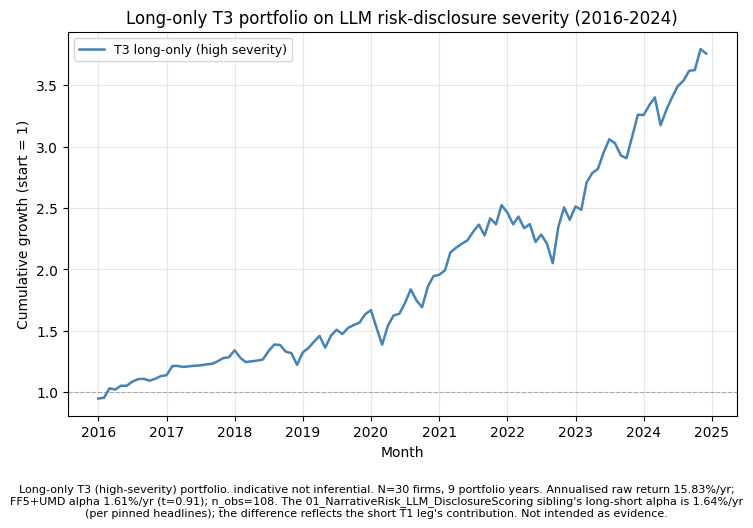

In [9]:
plot_long_only(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_long_only(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 10_NarrativeRisk_LLM_LongOnly
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> long_only_summary.csv + long_only.pdf
make test-all              # quantlet test suite
```
